In [3]:
import torch
import pandas as pd
from tqdm import tqdm

## define attacks

In [4]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# English -> German translator
model_name_en_de = "Helsinki-NLP/opus-mt-en-de"
trans_tokenizer_en_de = AutoTokenizer.from_pretrained(model_name_en_de)
trans_model_en_de = AutoModelForSeq2SeqLM.from_pretrained(
    model_name_en_de, 
    torch_dtype=torch.float16
).to(device)

def translate_en_de(text):
    # Tokenize and MOVE TO DEVICE
    inputs = trans_tokenizer_en_de(text, return_tensors="pt").to(device)
    translated_tokens = trans_model_en_de.generate(**inputs, max_new_tokens=128)
    return trans_tokenizer_en_de.batch_decode(translated_tokens, skip_special_tokens=True)[0]

# German -> English translator
model_name_de_en = "Helsinki-NLP/opus-mt-de-en"
trans_tokenizer_de_en = AutoTokenizer.from_pretrained(model_name_de_en)
trans_model_de_en = AutoModelForSeq2SeqLM.from_pretrained(
    model_name_de_en, 
    torch_dtype=torch.float16
).to(device)

def translate_de_en(text):
    # Tokenize and MOVE TO DEVICE
    inputs = trans_tokenizer_de_en(text, return_tensors="pt").to(device)
    translated_tokens = trans_model_de_en.generate(**inputs, max_new_tokens=128)
    return trans_tokenizer_de_en.batch_decode(translated_tokens, skip_special_tokens=True)[0]

# Example usage
text = "My name is Bob"
translated_text = translate_en_de(text)
print(translated_text)  # Output: 'Mein Name ist Bob.'

Using device: cuda


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Both `max_new_tokens` (=128) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Mein Name ist Bob.


In [5]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# Load the Flan-T5 model and tokenizer manually
model_name = "google/flan-t5-large"
style_tokenizer = AutoTokenizer.from_pretrained(model_name)
style_model = AutoModelForSeq2SeqLM.from_pretrained(model_name, torch_dtype=torch.float16)

# Optional: move model to GPU if available
style_model.to(device)

def generate_text(prompt, max_new_tokens=128, do_sample=True, top_k=50, top_p=0.95):
    """Generate text using Flan-T5, mimicking pipeline behavior."""
    inputs = style_tokenizer(prompt, return_tensors="pt").to(device)
    outputs = style_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        top_k=top_k,
        top_p=top_p
    )
    return style_tokenizer.decode(outputs[0], skip_special_tokens=True)

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


In [6]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
def back_translate(text):
    try:
        # Translate English to German
        de = translate_en_de(text)
        # Translate German back to English
        en = translate_de_en(de)
        return en
    except:
        return text

In [8]:
def paraphrase(text, num_return_sequences=2):
    try:
        outputs = paraphraser(
            text,
            max_length=128,
            num_return_sequences=num_return_sequences,
            do_sample=True,
            top_k=50,
            top_p=0.95
        )
        return [o['generated_text'] for o in outputs]
    except:
        return [text] * num_return_sequences

In [9]:
import random

def add_noise(text, prob=0.1):
    chars = list(text)
    for i in range(1, len(chars)):
        if random.random() < prob:
            chars[i], chars[i-1] = chars[i-1], chars[i]
    return "".join(chars)

In [10]:
def rewrite_to_human(text):
    prompt = f"While keeping the meaning the same, rewrite this to sound casual and human: {text}"
    return generate_text(prompt)

def rewrite_to_ai(text):
    prompt = f"While keeping the meaning the same, rewrite this to sound like it was written by AI: {text}"
    return generate_text(prompt)

In [11]:
# length bias

def truncate(text, max_words=30):
    return " ".join(text.split()[:max_words])

def expand(text):
    while len(text) < 700:
        text = text + " " + text
    return text

## get subset of data and generate adversarial data

In [12]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/data/cds" 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd
df = pd.read_csv(f"{DATA_DIR}/final_merged.csv")
rawtext = df["full_post_clean"].values
labels = df["Label"].values
print(type(rawtext))
print(type(labels))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Index(['author', 'created_utc', 'id', 'score', 'subreddit', 'Label',
       'interaction_type', 'full_post', 'post_id', 'full_post_clean'],
      dtype='object')

In [14]:
# get subset from full dataset

import random

N = 1000
indices = random.sample(range(len(rawtext)), N)

sample_texts = [rawtext[i] for i in indices]
sample_labels = [labels[i] for i in indices]

print(type(sample_texts))

<class 'list'>


In [15]:

# --- Optimized Batch Functions ---
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from tqdm import tqdm

# Load Paraphraser model explicitly for batching
para_model_name = "Vamsi/T5_Paraphrase_Paws"
para_tokenizer = AutoTokenizer.from_pretrained(para_model_name)
para_model = AutoModelForSeq2SeqLM.from_pretrained(para_model_name, torch_dtype=torch.float16).to(device)

def batch_generate(texts, model, tokenizer, batch_size=32, max_new_tokens=128, prefix=""):
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating Batches"):
        batch = [prefix + t for t in texts[i:i+batch_size]]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens)
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        results.extend(decoded)
    return results

def batch_back_translate(texts, batch_size=32):
    print("English -> German...")
    de_texts = batch_generate(texts, trans_model_en_de, trans_tokenizer_en_de, batch_size=batch_size)
    print("German -> English...")
    en_texts = batch_generate(de_texts, trans_model_de_en, trans_tokenizer_de_en, batch_size=batch_size)
    return en_texts

def batch_paraphrase(texts, batch_size=16, num_return_sequences=2):
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Paraphrasing"):
        batch = [f"paraphrase: {t}" for t in texts[i:i+batch_size]]
        inputs = para_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        with torch.no_grad():
            outputs = para_model.generate(
                **inputs, 
                max_new_tokens=128, 
                do_sample=True, 
                top_k=50, 
                top_p=0.95,
                num_return_sequences=num_return_sequences
            )
        decoded = para_tokenizer.batch_decode(outputs, skip_special_tokens=True)
        for j in range(0, len(decoded), num_return_sequences):
            results.append(decoded[j : j + num_return_sequences])
    return results

def batch_style_transfer(texts, target_style="human", batch_size=16):
    prefix = "While keeping the meaning the same, rewrite this to sound casual and human: " if target_style == "human" else "While keeping the meaning the same, rewrite this to sound like it was written by AI: "
    return batch_generate(texts, style_model, style_tokenizer, batch_size=batch_size, prefix=prefix)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

In [16]:

# --- Optimized Batched Generation ---
import os

print("Step 1: Back-translation...")
bt_texts = batch_back_translate(sample_texts, batch_size=32)

print("\nStep 2: Paraphrasing...")
para_results = batch_paraphrase(sample_texts, batch_size=16, num_return_sequences=2)
para1_texts = [p[0] for p in para_results]
para2_texts = [p[1] for p in para_results]

print("\nStep 3: Noise Injection...")
noise_texts = [add_noise(t) for t in tqdm(sample_texts, desc="Adding Noise")]

print("\nStep 4: Style Transfer...")
ai_indices = [i for i, l in enumerate(sample_labels) if l == 0]
human_indices = [i for i, l in enumerate(sample_labels) if l == 1]
style_texts = [None] * len(sample_texts)

if ai_indices:
    ai_to_human = batch_style_transfer([sample_texts[i] for i in ai_indices], target_style="human", batch_size=16)
    for idx, converted in zip(ai_indices, ai_to_human):
        style_texts[idx] = converted

if human_indices:
    human_to_ai = batch_style_transfer([sample_texts[i] for i in human_indices], target_style="ai", batch_size=16)
    for idx, converted in zip(human_indices, human_to_ai):
        style_texts[idx] = converted
        
print("\nGeneration Complete.")


Step 1: Back-translation...
English -> German...


Generating Batches: 100%|██████████| 32/32 [01:06<00:00,  2.08s/it]


German -> English...


Generating Batches: 100%|██████████| 32/32 [00:45<00:00,  1.41s/it]



Step 2: Paraphrasing...


...


Step 3: Noise Injection...


Adding Noise: 100%|██████████| 1000/1000 [00:00<00:00, 19701.93it/s]



Step 4: Style Transfer...


Generating Batches: 100%|██████████| 11/11 [01:06<00:00,  6.08s/it]


Generation Complete.


In [17]:
# create adversarial texts for length bias

short_texts = [truncate(t) for t in sample_texts]

long_texts = [expand(t) for t in sample_texts]

In [18]:
# tokenization

from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_adv_text(texts, labels):
    input_ids = []
    attention_masks = []

    for text in tqdm(texts, desc="Tokenization Progress"):
        # Simply call the tokenizer directly instead of using .encode_plus()
        encoded_dict = tokenizer(
            text,                      
            add_special_tokens = True, 
            max_length = 256,          
            padding = 'max_length',    # Updated to the modern parameter name
            truncation = True,
            return_attention_mask = True,   
            return_tensors = 'pt'     
        )
        
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    print("Concatenating tensors into memory...")
    # Convert the lists of tensors into a single massive PyTorch tensor
    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)

    print(f"Input IDs shape: {input_ids.shape}")
    print(f"Attention Masks shape: {attention_masks.shape}")
    print(f"Labels shape: {labels.shape}")

    return input_ids, attention_masks, labels

# tokenize the adversarial texts
bt_input_ids, bt_att_masks, bt_labels = tokenize_adv_text(bt_texts, sample_labels)
para1_input_ids, para1_att_masks, para1_labels = tokenize_adv_text(para1_texts, sample_labels)
para2_input_ids, para2_att_masks, para2_labels = tokenize_adv_text(para2_texts, sample_labels)
noise_input_ids, noise_att_masks, noise_labels = tokenize_adv_text(noise_texts, sample_labels)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization Progress: 100%|██████████| 1000/1000 [00:00<00:00, 1761.34it/s]


Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


...

Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


Tokenization Progress: 100%|██████████| 1000/1000 [00:00<00:00, 1812.07it/s]


Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


Tokenization Progress: 100%|██████████| 1000/1000 [00:00<00:00, 1117.10it/s]

Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


In [19]:
# tokenization for style attack

style_input_ids, style_att_masks, style_labels = tokenize_adv_text(style_texts, sample_labels)

Tokenization Progress: 100%|██████████| 1000/1000 [00:00<00:00, 1806.14it/s]

Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


In [20]:
# tokenization for length bias

short_inputs_ids, short_att_masks, short_labels = tokenize_adv_text(short_texts, sample_labels)
long_input_ids, long_att_masks, long_labels = tokenize_adv_text(long_texts, sample_labels)

Tokenization Progress: 100%|██████████| 1000/1000 [00:00<00:00, 1978.59it/s]


Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


Tokenization Progress: 100%|██████████| 1000/1000 [00:01<00:00, 797.40it/s]

Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


## dataset and dataloader

In [21]:
# Dataset and DataLoader for each of the adversarial texts
from torch.utils.data import Dataset, DataLoader, Subset

class PostsDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_masks': self.attention_masks[idx],
            'labels': self.labels[idx]
        }
    
    def __len__(self):
        return len(self.labels)

# create datasets
bt_dataset = PostsDataset(bt_input_ids, bt_att_masks, bt_labels)
para1_dataset = PostsDataset(para1_input_ids, para1_att_masks, para1_labels)
para2_dataset = PostsDataset(para2_input_ids, para2_att_masks, para2_labels)
noise_dataset = PostsDataset(noise_input_ids, noise_att_masks, noise_labels)

# create dataloaders
batch_size = 32
bt_loader = DataLoader(bt_dataset, batch_size=batch_size, shuffle=True)
para1_loader = DataLoader(para1_dataset, batch_size=batch_size, shuffle=True)
para2_loader = DataLoader(para2_dataset, batch_size=batch_size, shuffle=False)
noise_loader = DataLoader(noise_dataset, batch_size=batch_size, shuffle=False)

In [22]:
# dataset and dataloader for style attck
style_dataset = PostsDataset(style_input_ids, style_att_masks, style_labels)
style_loader = DataLoader(style_dataset, batch_size=batch_size, shuffle=True)

In [23]:
# dataset and dataloader for length bias
short_dataset = PostsDataset(short_inputs_ids, short_att_masks, short_labels)
long_dataset = PostsDataset(long_input_ids, long_att_masks, long_labels)

short_loader = DataLoader(short_dataset, batch_size=batch_size, shuffle=True)
long_loader = DataLoader(long_dataset, batch_size=batch_size, shuffle=True)

## model

In [24]:

CHECKPOINT_DIR = f"{DATA_DIR}/bert_checkpoints"
MODEL_FILE = f"{CHECKPOINT_DIR}/phase3_unfrozen_4.pt"

In [25]:
from transformers import AutoConfig, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.load_state_dict(torch.load(MODEL_FILE, weights_only=True))
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## testing on adversarial data

In [26]:
# testing

def test_adv_texts(model, loader, device):
    model.eval()

    test_loss = 0
    test_preds = []
    test_labels = []

    with torch.no_grad():

        for batch in tqdm(loader):

            input_ids = batch["input_ids"].to(device)
            attention_masks = batch["attention_masks"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_masks,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            test_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            test_preds.extend(preds.detach().cpu().numpy())
            test_labels.extend(labels.detach().cpu().numpy())

    return test_loss, test_preds, test_labels

In [27]:
bt_loss, bt_preds, bt_test_labels = test_adv_texts(model, bt_loader, device)
para1_loss, para1_preds, para1_test_labels = test_adv_texts(model, para1_loader, device)
para2_loss, para2_preds, para2_test_labels = test_adv_texts(model, para2_loader, device)
noise_loss, noise_preds, noise_test_labels = test_adv_texts(model, noise_loader, device)

100%|██████████| 32/32 [00:06<00:00,  4.66it/s]


In [28]:
style_loss, style_preds, style_test_labels = test_adv_texts(model, style_loader, device)

100%|██████████| 32/32 [00:06<00:00,  4.72it/s]


In [29]:
short_loss, short_preds, short_test_labels = test_adv_texts(model, short_loader, device)
long_loss, long_preds, long_test_labels = test_adv_texts(model, long_loader, device)

100%|██████████| 32/32 [00:06<00:00,  4.77it/s]


## results

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

def evaluate_on_testing_set(y_test, y_pred):
  # Calculate AUC
  print("AUC is: ", roc_auc_score(y_test, y_pred))

  # print out recall and precision
  print(classification_report(y_test, y_pred))

  # print out confusion matrix
  print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

  # # calculate points for ROC curve
  fpr, tpr, thresholds = roc_curve(y_test, y_pred)

  # Plot ROC curve
  plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc_score(y_test, y_pred))
  plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.0])
  plt.xlabel('False Positive Rate or (1 - Specifity)')
  plt.ylabel('True Positive Rate or (Sensitivity)')
  plt.title('Receiver Operating Characteristic')

Back translate loss: 6.012929188233102
AUC is:  0.972985347985348
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       832
           1       0.81      0.99      0.89       168

    accuracy                           0.96      1000
   macro avg       0.90      0.97      0.93      1000
weighted avg       0.97      0.96      0.96      1000

Confusion Matrix: 
 [[792  40]
 [  1 167]]


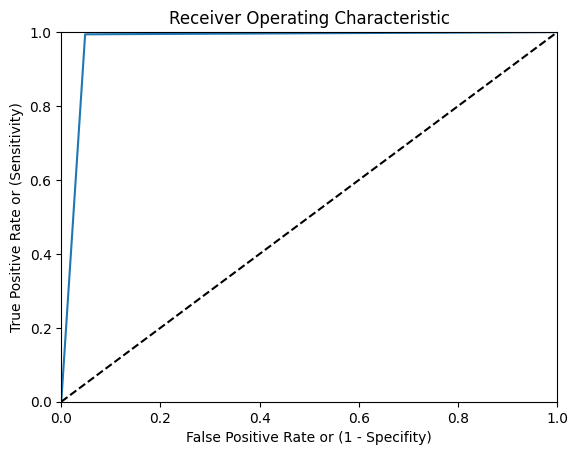

In [31]:
print("Back translate loss:", bt_loss)
evaluate_on_testing_set(bt_test_labels, bt_preds)

Paraphrase 1 loss: 1.5332975478668232
AUC is:  0.9880380036630036
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       832
           1       0.94      0.99      0.97       168

    accuracy                           0.99      1000
   macro avg       0.97      0.99      0.98      1000
weighted avg       0.99      0.99      0.99      1000

Confusion Matrix: 
 [[822  10]
 [  2 166]]


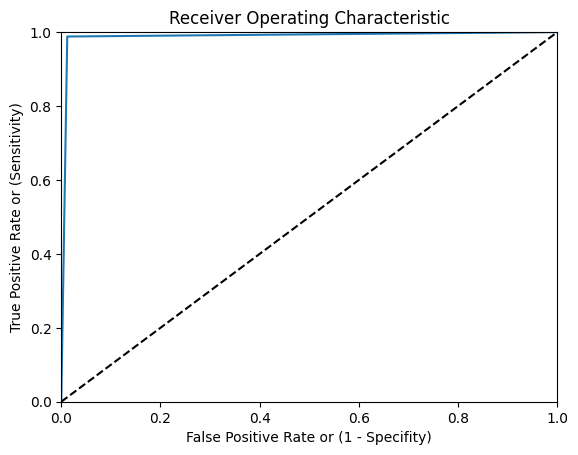

In [32]:
print("Paraphrase 1 loss:", para1_loss)
evaluate_on_testing_set(para1_test_labels, para1_preds)

Paraphrase 2 loss: 1.8916667995290481
AUC is:  0.9767342032967034
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       832
           1       0.95      0.96      0.96       168

    accuracy                           0.98      1000
   macro avg       0.97      0.98      0.97      1000
weighted avg       0.99      0.98      0.99      1000

Confusion Matrix: 
 [[823   9]
 [  6 162]]


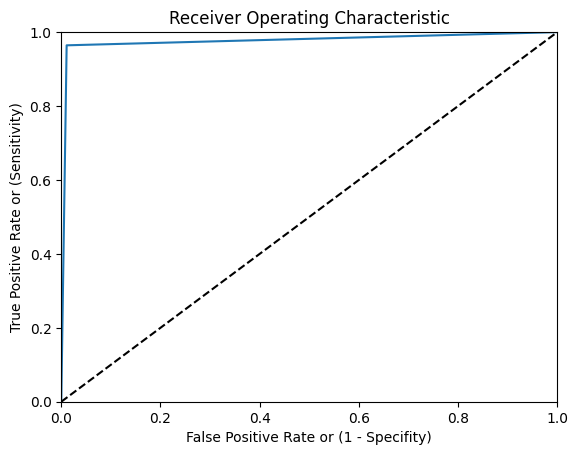

In [33]:
print("Paraphrase 2 loss:", para2_loss)
evaluate_on_testing_set(para2_test_labels, para2_preds)

Noise loss: 8.684069745635497
AUC is:  0.8130723443223443
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       832
           1       0.96      0.63      0.76       168

    accuracy                           0.93      1000
   macro avg       0.95      0.81      0.86      1000
weighted avg       0.94      0.93      0.93      1000

Confusion Matrix: 
 [[828   4]
 [ 62 106]]


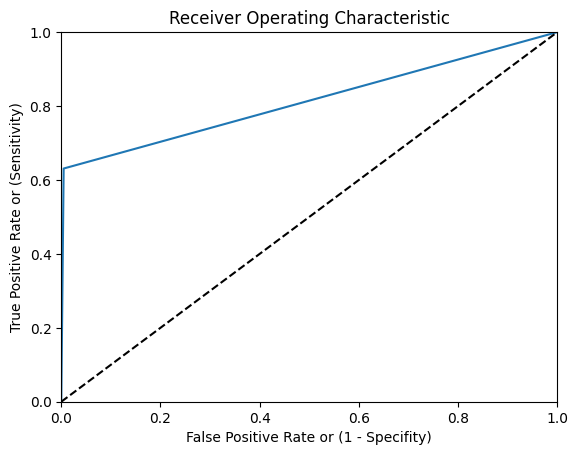

In [34]:
print("Noise loss:", noise_loss)
evaluate_on_testing_set(noise_test_labels, noise_preds)

Style loss: 3.3101345047034556
AUC is:  0.9487465659340658
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       832
           1       0.93      0.91      0.92       168

    accuracy                           0.97      1000
   macro avg       0.96      0.95      0.95      1000
weighted avg       0.97      0.97      0.97      1000

Confusion Matrix: 
 [[821  11]
 [ 15 153]]


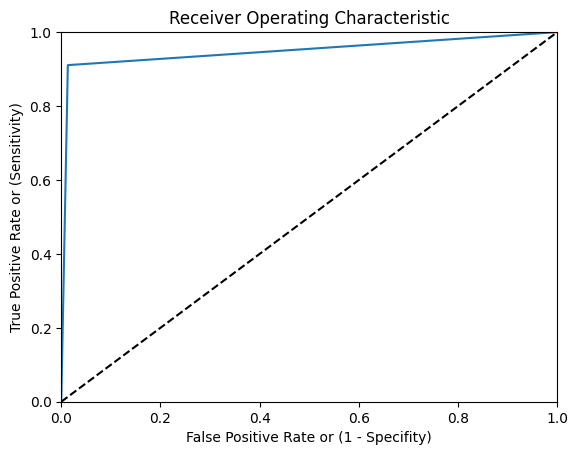

In [35]:
print("Style loss:", style_loss)
evaluate_on_testing_set(style_test_labels, style_preds)

Short length loss: 1.8779682342465094
AUC is:  0.9713827838827839
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       832
           1       0.95      0.95      0.95       168

    accuracy                           0.98      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.98      0.98      0.98      1000

Confusion Matrix: 
 [[824   8]
 [  8 160]]


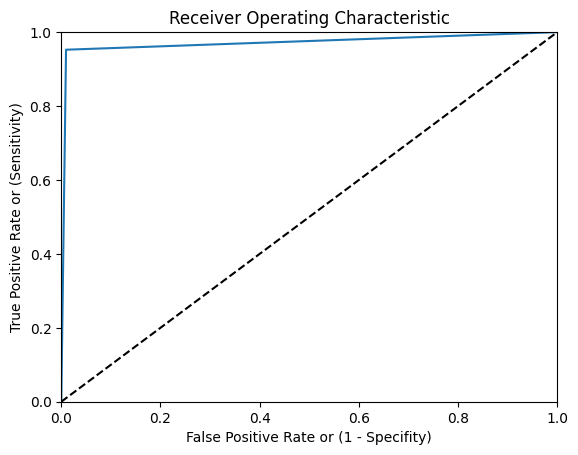

In [36]:
print("Short length loss:", short_loss)
evaluate_on_testing_set(short_test_labels, short_preds)

Long length loss: 7.953696133568883
AUC is:  0.9639423076923077
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       832
           1       0.74      1.00      0.85       168

    accuracy                           0.94      1000
   macro avg       0.87      0.96      0.91      1000
weighted avg       0.96      0.94      0.94      1000

Confusion Matrix: 
 [[772  60]
 [  0 168]]


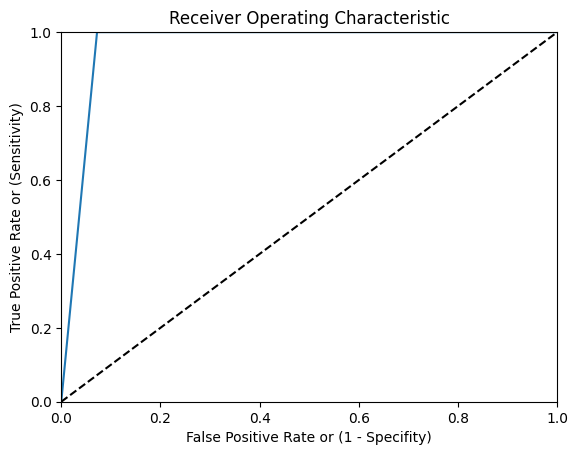

In [37]:
print("Long length loss:", long_loss)
evaluate_on_testing_set(long_test_labels, long_preds)

In [38]:
# get predictions for normal text
normal_input_ids, normal_att_masks, normal_labels = tokenize_adv_text(sample_texts, sample_labels)
normal_dataset = PostsDataset(normal_input_ids, normal_att_masks, normal_labels)
normal_loader = DataLoader(normal_dataset, batch_size=batch_size, shuffle=True)
normal_loss, normal_preds, normal_test_labels = test_adv_texts(model, normal_loader, device)

Tokenization Progress: 100%|██████████| 1000/1000 [00:00<00:00, 1270.86it/s]


Concatenating tensors into memory...
Input IDs shape: torch.Size([1000, 256])
Attention Masks shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


100%|██████████| 32/32 [00:06<00:00,  4.89it/s]


In [39]:
# compare if labelling increased or decreased 
from collections import Counter
print("Normal:", Counter(normal_preds))
print("Short text:", Counter(short_preds))
print("Long text:", Counter(long_preds))

Normal: Counter({np.int64(0): 830, np.int64(1): 170})
Short text: Counter({np.int64(0): 832, np.int64(1): 168})
Long text: Counter({np.int64(0): 772, np.int64(1): 228})


## Summary

class 0 = AI  
class 1 = human

|  | f1-score for 0 | f1-score for 1 | Accuracy | 
| --- | --- | --- | --- |
| Original | 1.0 | 0.98 | 0.99 |
| Back translation | 0.93 | 0.74 | 0.89 |
| Paraphrase 1 | 0.91 | 0.69 | **0.86** |
| Paraphrase 2 | 0.91 | 0.70 | 0.87 |
| Noise | 0.87 | 0.63 | **0.81** |
| Style transfer | 0.81 | 0.53 | **0.73** |
| Short text | 0.95 | 0.79 | 0.92 | 
| Long text | 0.98 | 0.90 | 0.97 |

For short text, class 0 labels decreased, class 1 labels increased -> more texts labelled as human   
For long text, class 0 labels increased, class 1 labels decreased -> more texts labelled as AI


## Adversarial Testing on New BERT Model (from ZIP)

Loading the model from `C:\Users\Rald999\Documents\GitHub\cds_project\data\bert_classification_model_complete-20260410T155433Z-3-001.zip` (extracted to `../data/bert_classification_model_complete`)

In [41]:
from transformers import AutoModelForSequenceClassification
import torch

NEW_MODEL_PATH = f'{DATA_DIR}/saved_model/bert_classification_model_complete'
model_new = AutoModelForSequenceClassification.from_pretrained(NEW_MODEL_PATH)
model_new.to(device)
model_new.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### Evaluation on Adversarial Sets

Evaluating Back Translation...


100%|██████████| 32/32 [00:06<00:00,  4.81it/s]

Back translate loss (New): 6.0129410637309775
AUC is:  0.972985347985348
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       832
           1       0.81      0.99      0.89       168

    accuracy                           0.96      1000
   macro avg       0.90      0.97      0.93      1000
weighted avg       0.97      0.96      0.96      1000

Confusion Matrix: 
 [[792  40]
 [  1 167]]


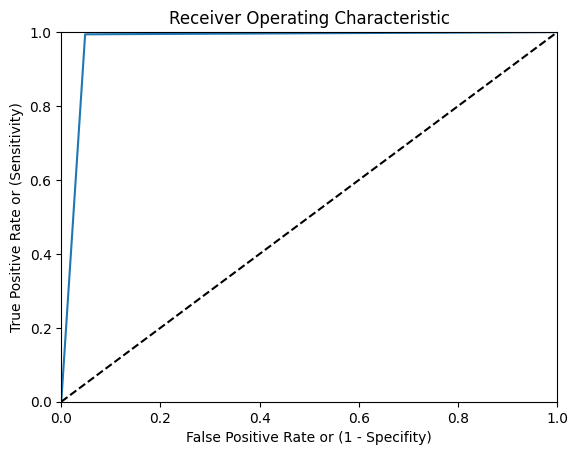

In [42]:
print('Evaluating Back Translation...')
bt_loss_n, bt_preds_n, bt_labels_n = test_adv_texts(model_new, bt_loader, device)
print('Back translate loss (New):', bt_loss_n)
evaluate_on_testing_set(bt_labels_n, bt_preds_n)

Evaluating Paraphrase 1...


100%|██████████| 32/32 [00:06<00:00,  4.76it/s]


Paraphrase 1 loss (New): 1.5332909839708009
AUC is:  0.9880380036630036
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       832
           1       0.94      0.99      0.97       168

    accuracy                           0.99      1000
   macro avg       0.97      0.99      0.98      1000
weighted avg       0.99      0.99      0.99      1000

Confusion Matrix: 
 [[822  10]
 [  2 166]]

Evaluating Paraphrase 2...


100%|██████████| 32/32 [00:06<00:00,  4.69it/s]

Paraphrase 2 loss (New): 1.8916667995290481
AUC is:  0.9767342032967034
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       832
           1       0.95      0.96      0.96       168

    accuracy                           0.98      1000
   macro avg       0.97      0.98      0.97      1000
weighted avg       0.99      0.98      0.99      1000

Confusion Matrix: 
 [[823   9]
 [  6 162]]


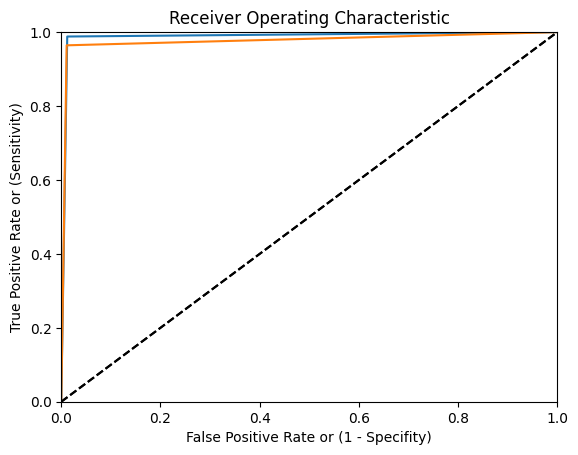

In [43]:
print('Evaluating Paraphrase 1...')
p1_loss_n, p1_preds_n, p1_labels_n = test_adv_texts(model_new, para1_loader, device)
print('Paraphrase 1 loss (New):', p1_loss_n)
evaluate_on_testing_set(p1_labels_n, p1_preds_n)

print('\nEvaluating Paraphrase 2...')
p2_loss_n, p2_preds_n, p2_labels_n = test_adv_texts(model_new, para2_loader, device)
print('Paraphrase 2 loss (New):', p2_loss_n)
evaluate_on_testing_set(p2_labels_n, p2_preds_n)

Evaluating Noise...


100%|██████████| 32/32 [00:06<00:00,  4.67it/s]


Noise loss (New): 8.684069745635497
AUC is:  0.8130723443223443
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       832
           1       0.96      0.63      0.76       168

    accuracy                           0.93      1000
   macro avg       0.95      0.81      0.86      1000
weighted avg       0.94      0.93      0.93      1000

Confusion Matrix: 
 [[828   4]
 [ 62 106]]


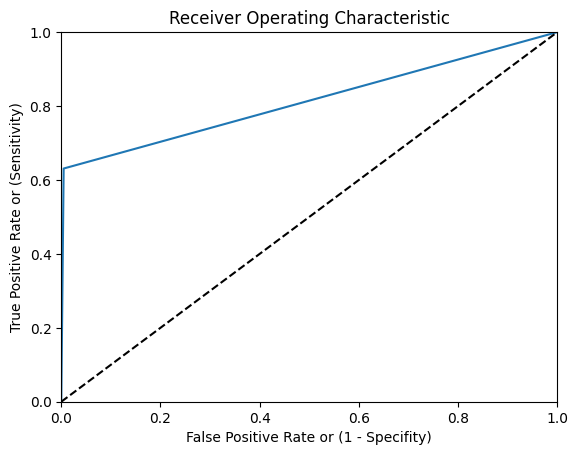

In [44]:
print('Evaluating Noise...')
noise_loss_n, noise_preds_n, noise_labels_n = test_adv_texts(model_new, noise_loader, device)
print('Noise loss (New):', noise_loss_n)
evaluate_on_testing_set(noise_labels_n, noise_preds_n)

Evaluating Style transfer...


100%|██████████| 32/32 [00:06<00:00,  4.68it/s]


Style transfer loss (New): 3.312117166322423
AUC is:  0.9487465659340658
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       832
           1       0.93      0.91      0.92       168

    accuracy                           0.97      1000
   macro avg       0.96      0.95      0.95      1000
weighted avg       0.97      0.97      0.97      1000

Confusion Matrix: 
 [[821  11]
 [ 15 153]]


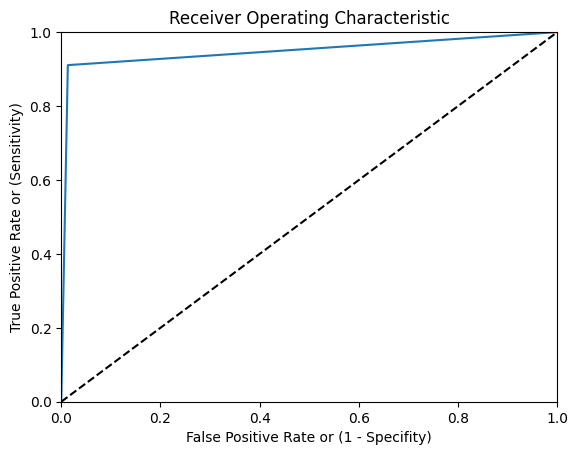

In [45]:
print('Evaluating Style transfer...')
style_loss_n, style_preds_n, style_labels_n = test_adv_texts(model_new, style_loader, device)
print('Style transfer loss (New):', style_loss_n)
evaluate_on_testing_set(style_labels_n, style_preds_n)

Evaluating Short text bias...


100%|██████████| 32/32 [00:06<00:00,  4.73it/s]


Short text loss (New): 1.879876083246927
AUC is:  0.9713827838827839
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       832
           1       0.95      0.95      0.95       168

    accuracy                           0.98      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.98      0.98      0.98      1000

Confusion Matrix: 
 [[824   8]
 [  8 160]]

Evaluating Long text bias...


100%|██████████| 32/32 [00:06<00:00,  4.71it/s]

Long text loss (New): 7.601706395857036
AUC is:  0.9639423076923077
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       832
           1       0.74      1.00      0.85       168

    accuracy                           0.94      1000
   macro avg       0.87      0.96      0.91      1000
weighted avg       0.96      0.94      0.94      1000

Confusion Matrix: 
 [[772  60]
 [  0 168]]


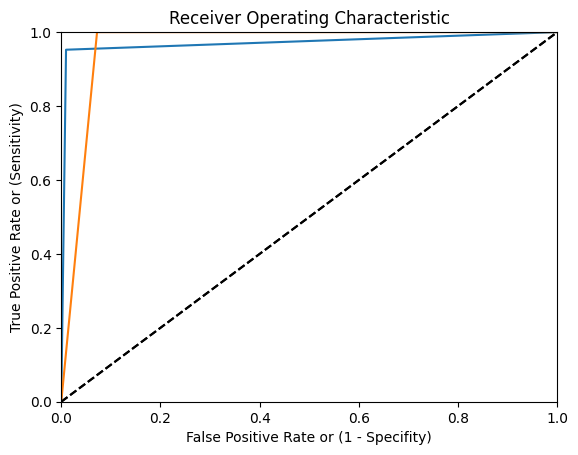

In [46]:
print('Evaluating Short text bias...')
short_loss_n, short_preds_n, short_labels_n = test_adv_texts(model_new, short_loader, device)
print('Short text loss (New):', short_loss_n)
evaluate_on_testing_set(short_labels_n, short_preds_n)

print('\nEvaluating Long text bias...')
long_loss_n, long_preds_n, long_labels_n = test_adv_texts(model_new, long_loader, device)
print('Long text loss (New):', long_loss_n)
evaluate_on_testing_set(long_labels_n, long_preds_n)